In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split   
df=pd.read_csv(r'preprocessed_data.csv')
print(df.head())

   Employee_ID  Age  Experience_Years Education  Department  Job_Level  \
0        10001   59                34  Bachelor   Marketing          9   
1        10002   49                29  Bachelor          HR          9   
2        10003   35                10  Bachelor          IT          4   
3        10004   28                 3    Master  Operations          1   
4        10005   41                18    Master          IT          5   

   Performance_Rating  Projects_Completed  Certifications  Weekly_Work_Hours  \
0                 3.7                  30              13               38.1   
1                 3.2                  25              10               48.3   
2                 3.1                  13               4               41.7   
3                 3.1                   7               3               41.8   
4                 2.6                  18               7               47.2   

  Remote_Work City_Tier  Job_Satisfaction  Salary_LPA Salary_Status  
0   

In [2]:
df.columns

Index(['Employee_ID', 'Age', 'Experience_Years', 'Education', 'Department',
       'Job_Level', 'Performance_Rating', 'Projects_Completed',
       'Certifications', 'Weekly_Work_Hours', 'Remote_Work', 'City_Tier',
       'Job_Satisfaction', 'Salary_LPA', 'Salary_Status'],
      dtype='str')

In [3]:
df.dtypes

Employee_ID             int64
Age                     int64
Experience_Years        int64
Education                 str
Department                str
Job_Level               int64
Performance_Rating    float64
Projects_Completed      int64
Certifications          int64
Weekly_Work_Hours     float64
Remote_Work               str
City_Tier                 str
Job_Satisfaction        int64
Salary_LPA            float64
Salary_Status             str
dtype: object

Intercept:  [-19.82785845]
Coefficients:  [[1.12660715]]

Accuracy: 0.972
Accuracy Percentage: 97.2 %

Actual vs Predicted Salary
   Experience_Years  Actual Salary_LPA  Actual Salary Class  \
0                21               2.27                    1   
1                 5               1.31                    0   
2                 0               0.81                    0   
3                34               2.50                    1   
4                 0               0.89                    0   
5                22               2.48                    1   
6                30               2.50                    1   
7                 0               0.65                    0   
8                39               2.50                    1   
9                 6               1.28                    0   

   Predicted Salary Class  
0                       1  
1                       0  
2                       0  
3                       1  
4                       0  
5       

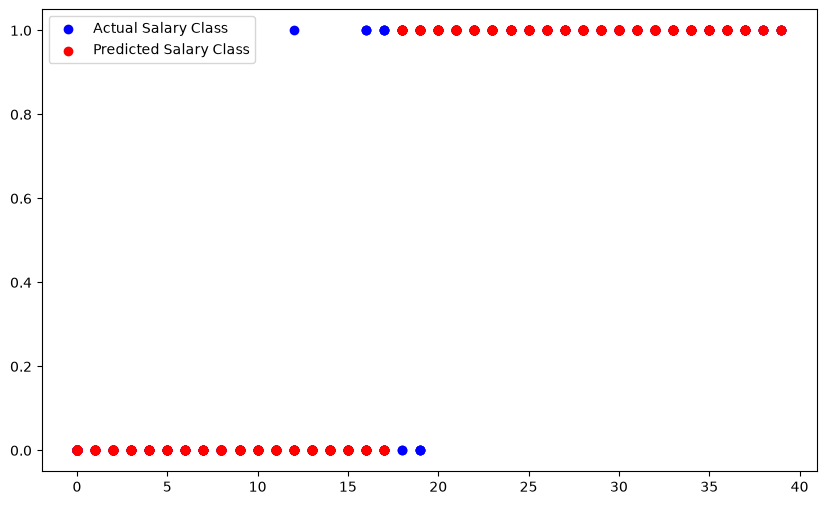

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
df["Salary_Class"] = (
    df["Salary_LPA"] >= df["Salary_LPA"].median()
).astype(int)

X = df[["Experience_Years"]]
y = df["Salary_Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Intercept: ", model.intercept_)
print("Coefficients: ", model.coef_)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

results = pd.DataFrame({
    "Experience_Years": X_test["Experience_Years"].values,
    "Actual Salary_LPA": df.loc[X_test.index, "Salary_LPA"].values,
    "Actual Salary Class": y_test.values,
    "Predicted Salary Class": y_pred
})

print("\nActual vs Predicted Salary")
print(results.head(10))

plt.figure(figsize=(10, 6))
plt.scatter(
    X_test["Experience_Years"],
    y_test,
    color="blue",
    label="Actual Salary Class"
)
plt.scatter(
    X_test["Experience_Years"],
    y_pred,
    color="red",
    label="Predicted Salary Class"
)
plt.xlabel = ("Experience_Years")
plt.ylabel = ("Salary Class")
plt.title = ("Actual vs Predicted Salary Class")
plt.legend()
plt.show()


In [5]:
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report , f1_score , recall_score , precision_score

In [6]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

confusion_matrix = confusion_matrix(y_test,y_pred)
print("Confusion matrix: ",confusion_matrix)

classification_report = classification_report(y_test,y_pred)
print("Classification_report: ",classification_report)

f1_score = f1_score(y_test,y_pred)
print("f1_score: ",f1_score)

recall_score = recall_score(y_test,y_pred)
print("recall_score:",recall_score)

precision_score = precision_score(y_test,y_pred)
print("precision_score: ",precision_score)

Accuracy: 0.972
Confusion matrix:  [[244   6]
 [  8 242]]
Classification_report:                precision    recall  f1-score   support

           0       0.97      0.98      0.97       250
           1       0.98      0.97      0.97       250

    accuracy                           0.97       500
   macro avg       0.97      0.97      0.97       500
weighted avg       0.97      0.97      0.97       500

f1_score:  0.9718875502008032
recall_score: 0.968
precision_score:  0.9758064516129032


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)



mean_absolute_error = mean_absolute_error(y_test, y_pred)

mean_squared_error = mean_squared_error(y_test, y_pred)

rmse = mean_squared_error ** 0.5

r2 = r2_score(y_test, y_pred)
print("MAE :", mean_absolute_error)
print("MSE :", mean_squared_error)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 0.028
MSE : 0.028
RMSE: 0.1673320053068151
R2 Score: 0.888


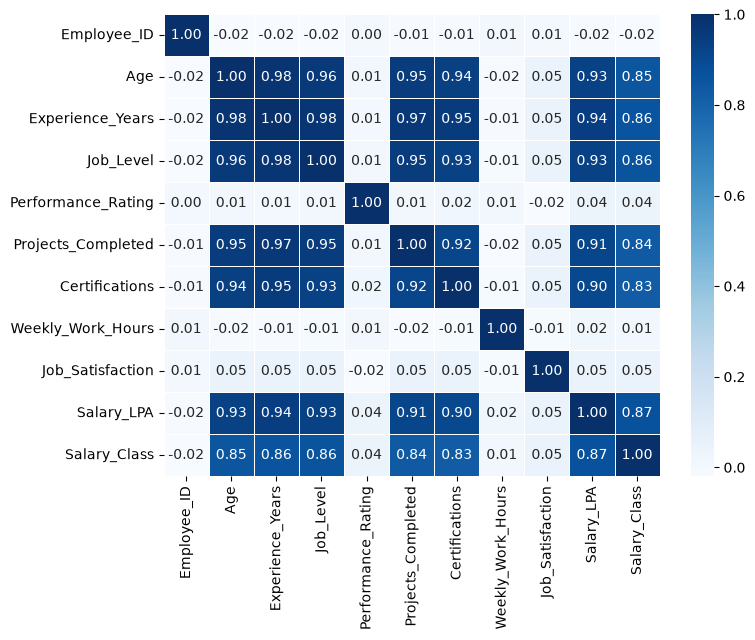

In [8]:
import  matplotlib.pyplot as plt
import seaborn as sns
corr_matrix=df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    linewidths=0.5
)
plt.title = ("correlation matrix")
plt.show()
